In [65]:
from watts.plugin_cyclus import ResultsCyclus
from watts.parameters import Parameters
from watts.results import ExecInfo, Results
import matplotlib.pyplot as plt
import numpy as np

In [66]:
inputs = []
outputs = ['./nuc46_nz50_ot2.sqlite']

obj = ResultsCyclus(Parameters(), ExecInfo(1, 'cyclus', 'name', 1),
                    inputs, outputs)
cyclus = obj.obj
natu_assay = 0.00711
tails_assay = 0.0025
years = np.array(range(int(cyclus.years[0]), int(cyclus.years[-1]) + 1))
min_year = 2020
years_idx = np.where(years >= min_year)[0]


# Group reactors per reactor type and fuel type

In [67]:

# Get all reactor prototype names used in the simulation
all_reactors = list(obj.reactors.values())

# Define named reactor categories of interest
named_reactors = ['AP1000', 'VOYGR', '12VOYGR', 'Natrium', 'XE100', '4XE100', 'VOGTLE-3', 'VOGTLE-4']

# Classify all remaining reactors as "Legacy"
legacy_protos = [r for r in all_reactors if r not in named_reactors]

# Group named reactors by name similarity (e.g., "VOYGR" and "12VOYGR")
grouped_reactors = {}
remaining = set(named_reactors)

# VOGTLE-3 and VOGTLE-4 are special, remove from remaining
remaining = remaining - {reactor for reactor in ['VOGTLE-3', 'VOGTLE-4'] if reactor in all_reactors}

while remaining:
    name = remaining.pop()
    # Collect all names containing or contained by `name`
    group = sorted({r for r in remaining | {name} if name in r or r in name})
    key = min(group, key=len)  # Use the shortest name as the group label
    grouped_reactors[key] = group
    remaining -= set(group) - {name}  # Remove grouped names (except current one, already popped)

# Add VOGTLE to AP1000 group
if 'VOGTLE-3' in all_reactors:
    grouped_reactors['AP1000'] += ['VOGTLE-3']
if 'VOGTLE-4' in all_reactors:
    grouped_reactors['AP1000'] += ['VOGTLE-4']

# Add legacy group explicitly
grouped_reactors['Legacy'] = legacy_protos

# Sort by number of reactors in each group, descending
grouped_reactors = dict(sorted(grouped_reactors.items(), key=lambda item: len(item[1]), reverse=True))

# Super groups
supergrouped_reactors = {
    'UOX': grouped_reactors['AP1000'] + grouped_reactors['VOYGR'] + grouped_reactors['Legacy'],
    'Metal': grouped_reactors['Natrium'],
    'TRISO': grouped_reactors['XE100']
}    

# Fuel demand

{'AP1000': array([      0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,   84775.,
          33910.,  203460.,   67820.,  271280.,  186505.,  423875.,
         406920.,  356055.,  440830.,  423875.,  627335.,  491695.,
         729065.,  593425.,  796885., 

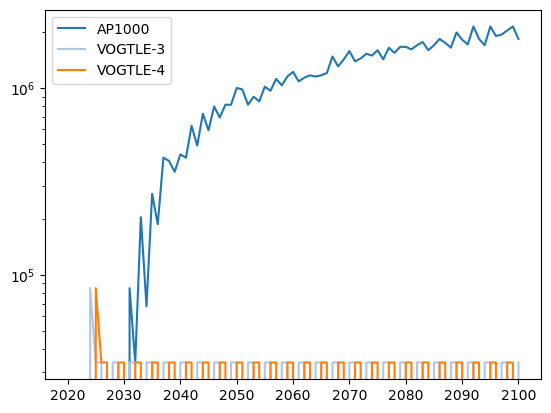

In [68]:
# Separate: example with AP1000

fuel_demand_legacy = cyclus.stock_fuel_demand(grouped_reactors['AP1000'], return_sum=False) # By default, returns the sum of all reactors
for reactor, demand in fuel_demand_legacy.items():
    plt.semilogy(years[years_idx], demand[years_idx], label=reactor)
plt.legend()
fuel_demand_legacy

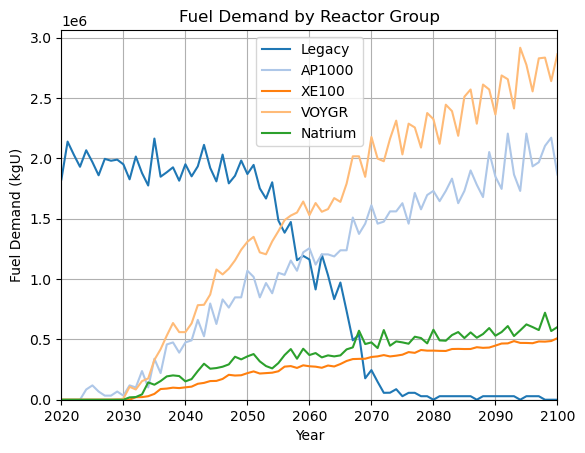

In [69]:
# Summed
fuel_demand = {}
for group, reactors in grouped_reactors.items():
    fuel_demand[group] = cyclus.stock_fuel_demand(reactors, return_sum=True)
    
for group, demand in fuel_demand.items():
    plt.plot(years[years_idx], demand[years_idx], label=group)
plt.xlabel('Year')
plt.ylabel('Fuel Demand (kgU)')
plt.title('Fuel Demand by Reactor Group')
plt.xlim(min_year, years[-1])
plt.ylim(0, None)
plt.grid()
plt.legend()

# Discharged fuel

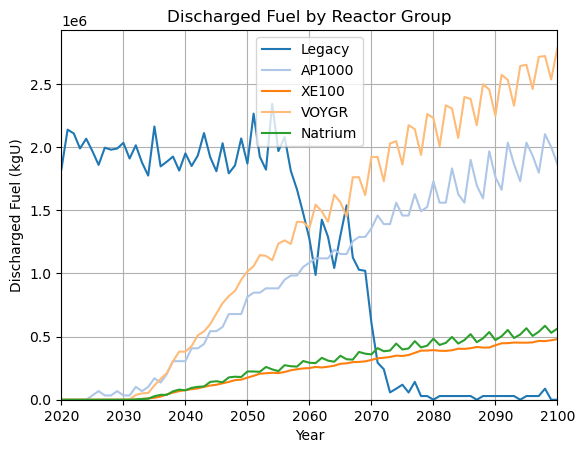

In [70]:
# Summed
discharged_fuel = {}
for group, reactors in grouped_reactors.items():
    discharged_fuel[group] = cyclus.stock_fuel_discharged(reactors)
    
for group, discharge in discharged_fuel.items():
    plt.plot(years[years_idx], discharge[years_idx], label=group)
plt.xlabel('Year')
plt.ylabel('Discharged Fuel (kgU)')
plt.title('Discharged Fuel by Reactor Group')
plt.xlim(min_year, years[-1])
plt.ylim(0, None)
plt.grid()
plt.legend()

# Uranium Ore

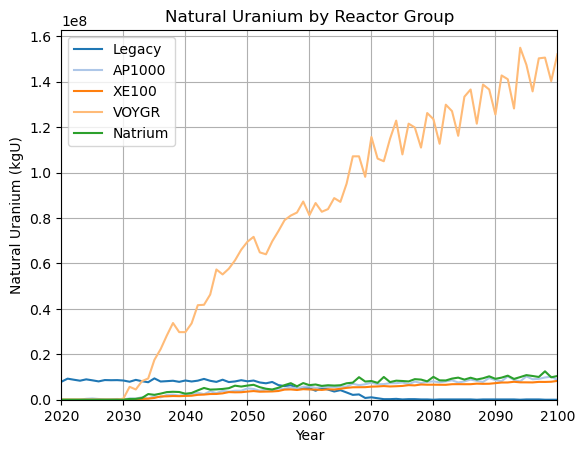

In [71]:
# Summed
natural_uranium = {}
for group, reactors in grouped_reactors.items():
    natural_uranium[group] = cyclus.stock_fuel_natu(reactors, natu_assay=natu_assay, tails_assay=tails_assay)
    
for group, nat_uranium in natural_uranium.items():
    plt.plot(years[years_idx], nat_uranium[years_idx], label=group)
plt.xlabel('Year')
plt.ylabel('Natural Uranium (kgU)')
plt.title('Natural Uranium by Reactor Group')
plt.xlim(min_year, years[-1])
plt.ylim(0, None)
plt.grid()
plt.legend()


# Tails 


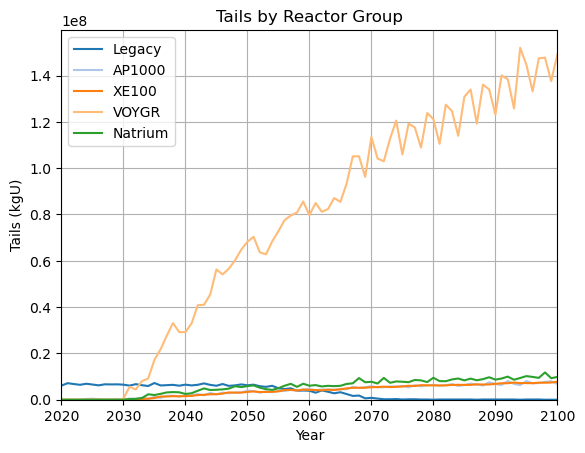

In [72]:
tails = {}
for group, reactors in grouped_reactors.items():
    tails[group] = cyclus.stock_fuel_tails(reactors, natu_assay=natu_assay, tails_assay=tails_assay)
for group, tail in tails.items():
    plt.plot(years[years_idx], tail[years_idx], label=group)
plt.xlabel('Year')
plt.ylabel('Tails (kgU)')
plt.title('Tails by Reactor Group')
plt.xlim(min_year, years[-1])
plt.ylim(0, None)
plt.grid()
plt.legend()

# SWU

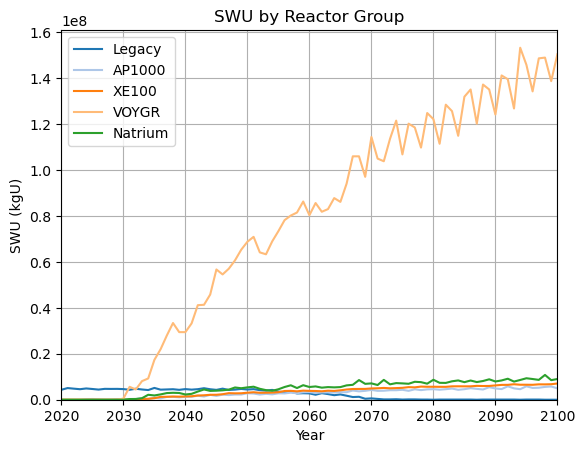

In [73]:
swu = {}
for group, reactors in grouped_reactors.items():
    swu[group] = cyclus.stock_fuel_swu(reactors, natu_assay=natu_assay, tails_assay=tails_assay)
for group, swu_ in swu.items():
    plt.plot(years[years_idx], swu_[years_idx], label=group)
plt.xlabel('Year')
plt.ylabel('SWU (kgU)')
plt.title('SWU by Reactor Group')
plt.xlim(min_year, years[-1])
plt.ylim(0, None)
plt.grid()
plt.legend()

# Same per fuel type

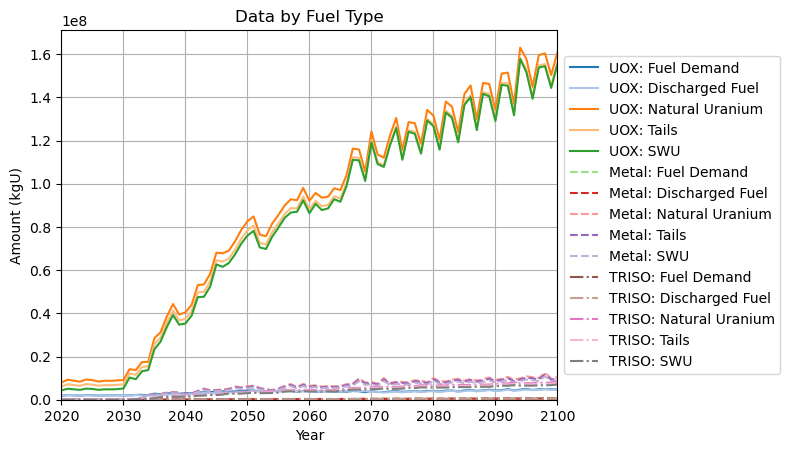

In [74]:
fuel_demand_per_fuel_type = {}
discharged_fuel_per_fuel_type = {}
natural_uranium_per_fuel_type = {}
tails_per_fuel_type = {}
swu_per_fuel_type = {}
for fuel_type, reactors in supergrouped_reactors.items():
    fuel_demand_per_fuel_type[fuel_type] = cyclus.stock_fuel_demand(reactors)
    discharged_fuel_per_fuel_type[fuel_type] = cyclus.stock_fuel_discharged(reactors)
    natural_uranium_per_fuel_type[fuel_type] = cyclus.stock_fuel_natu(reactors, natu_assay=natu_assay, tails_assay=tails_assay)
    tails_per_fuel_type[fuel_type] = cyclus.stock_fuel_tails(reactors, natu_assay=natu_assay, tails_assay=tails_assay)
    swu_per_fuel_type[fuel_type] = cyclus.stock_fuel_swu(reactors, natu_assay=natu_assay, tails_assay=tails_assay)

# Plotting all on the same graph
linestyles = ['-', '--', '-.', ':']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab20.colors)
for i, (fuel_type, discharge) in enumerate(fuel_demand_per_fuel_type.items()):
    plt.plot(years[years_idx], discharge[years_idx], label=f'{fuel_type}: Fuel Demand', linestyle=linestyles[i % len(linestyles)])
    plt.plot(years[years_idx], discharged_fuel_per_fuel_type[fuel_type][years_idx], label=f'{fuel_type}: Discharged Fuel', linestyle=linestyles[i % len(linestyles)])
    plt.plot(years[years_idx], natural_uranium_per_fuel_type[fuel_type][years_idx], label=f'{fuel_type}: Natural Uranium', linestyle=linestyles[i % len(linestyles)])
    plt.plot(years[years_idx], tails_per_fuel_type[fuel_type][years_idx], label=f'{fuel_type}: Tails', linestyle=linestyles[i % len(linestyles)])
    plt.plot(years[years_idx], swu_per_fuel_type[fuel_type][years_idx], label=f'{fuel_type}: SWU', linestyle=linestyles[i % len(linestyles)])
plt.xlabel('Year')
plt.ylabel('Amount (kgU)')
plt.title('Data by Fuel Type')
plt.xlim(min_year, years[-1])
plt.ylim(0, None)
plt.grid()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))